# F6 Prequential Evaluation — Neural Network (50 Configurations)

## Overview

**Function 6**: Cake recipe scoring — 5 ingredient inputs (flour, sugar, eggs, butter, milk), composite negative score output.  
**Objective**: Maximise (bring score closest to 0).

This notebook performs **prequential (one-step-ahead) evaluation** of a Neural Network surrogate with **MC Dropout** uncertainty estimation across **50 hyperparameter configurations**.

### Approach

For each configuration:
1. Train on initial 20 points
2. Predict next unseen point (mean + uncertainty via MC Dropout)
3. Add actual observation to training set
4. Repeat for all 6 evaluation steps

### Hyperparameter Search Space

50 configurations varying three axes:

| Axis | Values |
|------|--------|
| **Hidden layers** | 1, 2 |
| **Nodes per layer** | 5, 8, 16, 32, 64 |
| **Learning rate** | 0.001, 0.005, 0.01, 0.05, 0.1 |

**Fixed**: Activation=ReLU, Dropout=0.2, Epochs=500, MC samples=50, Normalisation=z-score

### Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean(\|predicted − actual\|) | Lower is better — point prediction accuracy |
| **NLP** | −log p(actual \| predicted, σ) | Lower is better — calibration quality (primary) |
| **95% Coverage** | fraction within ±1.96σ | Closer to 95% is better — interval reliability |

## Imports

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# BoTorch / GPyTorch for GP models
from botorch.models import SingleTaskGP, SingleTaskMultiFidelityGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.kernels import MaternKernel, RBFKernel, ScaleKernel

warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

print('All imports successful.')

All imports successful.


## Data Loading

Load F6 data (Week 6) — 26 total samples, first 20 used as initial training set.

In [16]:
# ── Load F6 data (Week 6) ────────────────────────────────────
WEEK = 6
X_all = np.load(f'../../data/f6/updated_inputs - Week {WEEK}.npy')
y_all = np.load(f'../../data/f6/updated_outputs - Week {WEEK}.npy')

N_INIT = 20  # Initial training points
n_total = len(y_all)
n_steps = n_total - N_INIT  # Evaluation steps

print(f'Function 6 — Cake Recipe Scoring (5D)')
print(f'  Data loaded: Week {WEEK}')
print(f'  X shape: {X_all.shape}  (input dimensions: {X_all.shape[1]})')
print(f'  y shape: {y_all.shape}')
print(f'  Output range: [{y_all.min():.6f}, {y_all.max():.6f}]')
print(f'  Output mean:  {y_all.mean():.6f}')
print(f'  Output std:   {y_all.std():.6f}')
print(f'  Output Var:   {y_all.var():.6f}')
print(f'  Initial training points: {N_INIT}')
print(f'  Evaluation steps: {n_steps}')

Function 6 — Cake Recipe Scoring (5D)
  Data loaded: Week 6
  X shape: (26, 5)  (input dimensions: 5)
  y shape: (26,)
  Output range: [-2.571170, -0.219187]
  Output mean:  -1.315961
  Output std:   0.545619
  Output Var:   0.297700
  Initial training points: 20
  Evaluation steps: 6


## Metrics Function

In [17]:
def compute_metrics(predictions, actuals, stds):
    """Compute MAE, NLP, and 95% coverage.
    
    Args:
        predictions: array of predicted means
        actuals: array of actual values
        stds: array of predicted standard deviations
    
    Returns:
        dict with MAE, NLP, Coverage_95
    """
    errors = np.abs(predictions - actuals)
    mae = np.mean(errors)
    
    # Negative log predictive density (Gaussian assumption)
    clipped_stds = np.maximum(stds, 1e-10)
    nlp = 0.5 * np.log(2 * np.pi * clipped_stds**2) + \
          0.5 * ((actuals - predictions) / clipped_stds)**2
    mean_nlp = np.mean(nlp)
    
    # 95% coverage
    lower = predictions - 1.96 * clipped_stds
    upper = predictions + 1.96 * clipped_stds
    coverage = np.mean((actuals >= lower) & (actuals <= upper))
    
    return {'MAE': mae, 'NLP': mean_nlp, 'Coverage_95': coverage}

print('compute_metrics() defined.')

compute_metrics() defined.


## Neural Network — Default Configuration

Starting configuration: **2 hidden layers, 5 nodes per layer, lr=0.01**

### Architecture

The `FlexibleNN` class builds an NN with a configurable number of hidden layers, each with the same number of nodes:

```
Input(5) → [Linear(5→n_nodes) → ReLU → Dropout(0.2)] × n_layers → Linear(n_nodes→1)
```

### Uncertainty via MC Dropout

At inference, the model is kept in `train()` mode (dropout active). 50 stochastic forward passes produce a distribution of predictions:
- **Mean prediction** = mean of 50 passes
- **Uncertainty (std)** = std of 50 passes

This provides a non-parametric uncertainty estimate without requiring a separate probabilistic model.

In [18]:
# ── Flexible NN architecture ──────────────────────────────────
class FlexibleNN(nn.Module):
    """Neural network with configurable hidden layers and nodes.
    
    Args:
        input_dim: Number of input features
        n_layers: Number of hidden layers
        n_nodes: Number of nodes per hidden layer
        dropout: Dropout probability (default 0.2)
    """
    def __init__(self, input_dim, n_layers, n_nodes, dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for _ in range(n_layers):
            layers.extend([
                nn.Linear(prev_dim, n_nodes),
                nn.ReLU(),
                nn.Dropout(p=dropout)
            ])
            prev_dim = n_nodes
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


# ── Prequential evaluation function ───────────────────────────
MC_SAMPLES = 50
EPOCHS = 500

def nn_prequential_with_config(X_all, y_all, n_init, config):
    """Run prequential evaluation with a given NN configuration.
    
    Args:
        X_all: Full input array (n_total, input_dim)
        y_all: Full output array (n_total,)
        n_init: Number of initial training points
        config: dict with keys 'n_layers', 'n_nodes', 'lr', 'label'
    
    Returns:
        dict with predictions, actuals, stds, metrics
    """
    input_dim = X_all.shape[1]
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    stds = []
    
    for step in range(n_steps):
        # Current training data
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        
        # Test point (next unseen)
        X_test = X_all[n_train:n_train+1]
        y_test = y_all[n_train]
        
        # z-score normalisation (fit on training data only)
        X_mean = X_train.mean(axis=0)
        X_std = X_train.std(axis=0) + 1e-10
        y_mean = y_train.mean()
        y_std = y_train.std() + 1e-10
        
        X_train_norm = (X_train - X_mean) / X_std
        y_train_norm = (y_train - y_mean) / y_std
        X_test_norm = (X_test - X_mean) / X_std
        
        # Convert to tensors
        X_t = torch.tensor(X_train_norm, dtype=torch.float32)
        y_t = torch.tensor(y_train_norm, dtype=torch.float32).unsqueeze(1)
        X_test_t = torch.tensor(X_test_norm, dtype=torch.float32)
        
        # Build and train model
        torch.manual_seed(42 + step)  # Reproducible per step
        model = FlexibleNN(input_dim, config['n_layers'], config['n_nodes'])
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
        criterion = nn.MSELoss()
        
        model.train()
        for epoch in range(EPOCHS):
            optimizer.zero_grad()
            pred = model(X_t)
            loss = criterion(pred, y_t)
            loss.backward()
            optimizer.step()
        
        # MC Dropout prediction (keep model in train mode)
        model.train()  # Dropout active
        mc_preds = []
        with torch.no_grad():
            for _ in range(MC_SAMPLES):
                p = model(X_test_t).squeeze().item()
                mc_preds.append(p)
        
        mc_preds = np.array(mc_preds)
        # Denormalise
        mc_preds_orig = mc_preds * y_std + y_mean
        
        mean_pred = mc_preds_orig.mean()
        std_pred = max(mc_preds_orig.std(), 1e-10)
        
        predictions.append(mean_pred)
        actuals.append(y_test)
        stds.append(std_pred)
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    stds = np.array(stds)
    
    metrics = compute_metrics(predictions, actuals, stds)
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'stds': stds,
        'metrics': metrics
    }


# ── Run default configuration ─────────────────────────────────
default_config = {'n_layers': 2, 'n_nodes': 5, 'lr': 0.01, 'label': 'NN: 2L×5N, lr=0.01 (default)'}

print(f"Running NN default ({default_config['label']}) prequential evaluation...")
print(f'  Training starts with {N_INIT} points, evaluating {n_steps} steps\n')

nn_default_results = nn_prequential_with_config(X_all, y_all, N_INIT, default_config)

for step in range(n_steps):
    pred = nn_default_results['predictions'][step]
    actual = nn_default_results['actuals'][step]
    error = pred - actual
    std = nn_default_results['stds'][step]
    print(f'  Step {step+1}: train={N_INIT+step} pts | predicted={pred:+.6f} | actual={actual:+.6f} | error={error:+.6f} | std={std:.6f}')

metrics = nn_default_results['metrics']
print(f"\n  Results:")
print(f"    MAE:          {metrics['MAE']:.6f}")
print(f"    Mean NLP:     {metrics['NLP']:.4f}")
print(f"    95% Coverage: {metrics['Coverage_95']*100:.1f}%")

Running NN default (NN: 2L×5N, lr=0.01 (default)) prequential evaluation...
  Training starts with 20 points, evaluating 6 steps

  Step 1: train=20 pts | predicted=-1.529070 | actual=-1.445052 | error=-0.084017 | std=0.064801
  Step 2: train=21 pts | predicted=-0.680577 | actual=-0.454130 | error=-0.226448 | std=0.291173
  Step 3: train=22 pts | predicted=-0.407701 | actual=-0.945770 | error=+0.538069 | std=0.567443
  Step 4: train=23 pts | predicted=-0.866574 | actual=-0.636347 | error=-0.230227 | std=0.268183
  Step 5: train=24 pts | predicted=-0.976345 | actual=-0.219187 | error=-0.757158 | std=0.174318
  Step 6: train=25 pts | predicted=-0.670226 | actual=-0.606701 | error=-0.063525 | std=0.497153

  Results:
    MAE:          0.316574
    Mean NLP:     1.4362
    95% Coverage: 83.3%


### Default Configuration — Prequential Visualisation

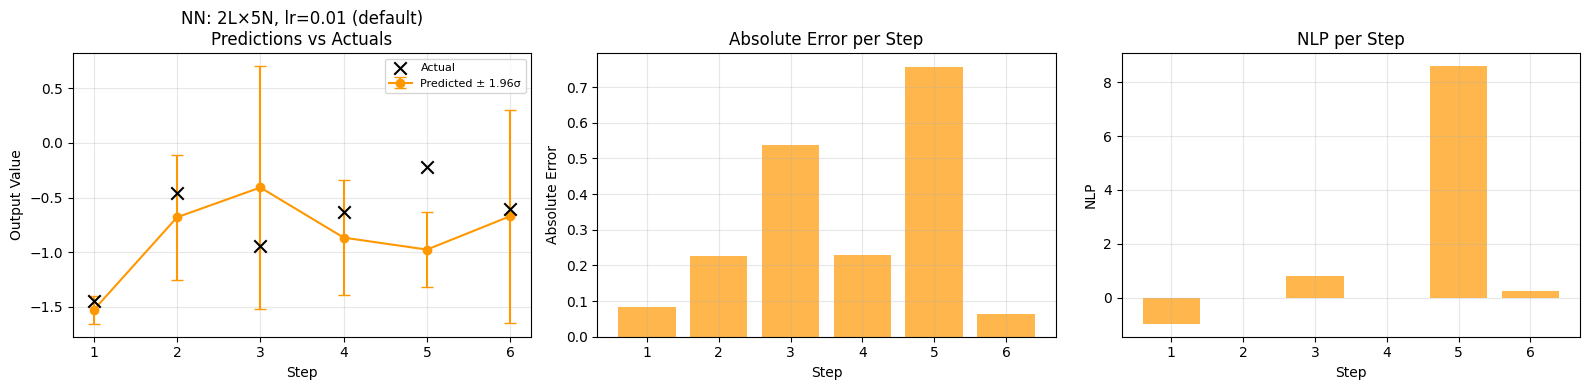

In [19]:
# ── Plot prequential results for default config ───────────────
def plot_prequential_results(results, label, color='#FF9800'):
    """Plot 3-panel prequential evaluation results."""
    preds = results['predictions']
    acts = results['actuals']
    stds_arr = results['stds']
    steps = np.arange(1, len(preds) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Panel 1: Predictions vs Actuals
    axes[0].errorbar(steps, preds, yerr=1.96*stds_arr, fmt='o-', color=color,
                     capsize=4, label='Predicted ± 1.96σ', markersize=6)
    axes[0].scatter(steps, acts, color='black', marker='x', s=80, zorder=5, label='Actual')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Output Value')
    axes[0].set_title(f'{label}\nPredictions vs Actuals')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: Absolute Error
    abs_errors = np.abs(preds - acts)
    axes[1].bar(steps, abs_errors, color=color, alpha=0.7)
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Absolute Error')
    axes[1].set_title('Absolute Error per Step')
    axes[1].grid(True, alpha=0.3)
    
    # Panel 3: NLP per step
    clipped = np.maximum(stds_arr, 1e-10)
    nlp_step = 0.5 * np.log(2 * np.pi * clipped**2) + \
               0.5 * ((acts - preds) / clipped)**2
    axes[2].bar(steps, nlp_step, color=color, alpha=0.7)
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('NLP')
    axes[2].set_title('NLP per Step')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_prequential_results(nn_default_results, default_config['label'])

## Neural Network HP Optimisation — 45 Configurations

Systematic grid over three hyperparameter axes:

| Axis | Values | Count |
|------|--------|-------|
| **Hidden layers** | 1, 2, 3 | 3 |
| **Nodes per layer** | 4, 5, 6 | 3 |
| **Learning rate** | 0.001, 0.005, 0.01, 0.05, 0.1 | 5 |

**Total**: 3 × 3 × 5 = **45 configurations**

All other hyperparameters are held constant:
- Activation: ReLU
- Dropout: 0.2 (required for MC Dropout uncertainty)
- Training epochs: 500
- MC forward passes: 50
- Input/output normalisation: z-score

In [20]:
# ── Generate 45 NN configurations ─────────────────────────────
layers_grid = [1, 2, 3]
nodes_grid = [4, 5, 6]
lr_grid = [0.001, 0.005, 0.01, 0.05, 0.1]

nn_configs = []
for n_layers in layers_grid:
    for n_nodes in nodes_grid:
        for lr in lr_grid:
            label = f'NN: {n_layers}L×{n_nodes}N, lr={lr}'
            nn_configs.append({
                'n_layers': n_layers,
                'n_nodes': n_nodes,
                'lr': lr,
                'label': label
            })

print(f'Generated {len(nn_configs)} NN configurations.\n')

# ── Evaluate all 45 configurations ────────────────────────────
print(f'Running {len(nn_configs)} NN configurations...\n')

nn_results = []
for i, config in enumerate(nn_configs):
    try:
        result = nn_prequential_with_config(X_all, y_all, N_INIT, config)
        m = result['metrics']
        print(f'  [{i+1:2d}/{len(nn_configs)}] {config["label"]} ... '
              f'MAE={m["MAE"]:.4f}, NLP={m["NLP"]:.4f}, Cov={m["Coverage_95"]*100:.1f}%')
        nn_results.append({
            'label': config['label'],
            'MAE': m['MAE'],
            'NLP': m['NLP'],
            'Coverage_95': m['Coverage_95']
        })
    except Exception as e:
        print(f'  [{i+1:2d}/{len(nn_configs)}] {config["label"]} ... FAILED: {e}')
        nn_results.append({
            'label': config['label'],
            'MAE': float('nan'),
            'NLP': float('nan'),
            'Coverage_95': float('nan')
        })

nn_hp_df = pd.DataFrame(nn_results)
print(f'\nNN Hyperparameter Results ({len(nn_hp_df)} configs):\n')
nn_hp_df

Generated 45 NN configurations.

Running 45 NN configurations...

  [ 1/45] NN: 1L×4N, lr=0.001 ... MAE=0.4024, NLP=14.0853, Cov=50.0%
  [ 2/45] NN: 1L×4N, lr=0.005 ... MAE=0.3623, NLP=2.2335, Cov=66.7%
  [ 3/45] NN: 1L×4N, lr=0.01 ... MAE=0.3783, NLP=2.2000, Cov=83.3%
  [ 4/45] NN: 1L×4N, lr=0.05 ... MAE=0.4312, NLP=3.4072, Cov=83.3%
  [ 5/45] NN: 1L×4N, lr=0.1 ... MAE=0.3575, NLP=4.8172, Cov=83.3%
  [ 6/45] NN: 1L×5N, lr=0.001 ... MAE=0.3945, NLP=5.0862, Cov=50.0%
  [ 7/45] NN: 1L×5N, lr=0.005 ... MAE=0.3876, NLP=2.6052, Cov=50.0%
  [ 8/45] NN: 1L×5N, lr=0.01 ... MAE=0.3761, NLP=3.0193, Cov=66.7%
  [ 9/45] NN: 1L×5N, lr=0.05 ... MAE=0.4209, NLP=2.5904, Cov=83.3%
  [10/45] NN: 1L×5N, lr=0.1 ... MAE=0.4175, NLP=2.5529, Cov=66.7%
  [11/45] NN: 1L×6N, lr=0.001 ... MAE=0.4139, NLP=2980.5808, Cov=33.3%
  [12/45] NN: 1L×6N, lr=0.005 ... MAE=0.3783, NLP=20.7724, Cov=33.3%
  [13/45] NN: 1L×6N, lr=0.01 ... MAE=0.3728, NLP=708292196946422528.0000, Cov=33.3%
  [14/45] NN: 1L×6N, lr=0.05 ... MAE=

,label,MAE,NLP,Coverage_95
0,"NN: 1L×4N, lr=0.001",0.402361,1.408529e+01,0.500000
1,"NN: 1L×4N, lr=0.005",0.362292,2.233476e+00,0.666667
2,"NN: 1L×4N, lr=0.01",0.378307,2.199972e+00,0.833333
3,"NN: 1L×4N, lr=0.05",0.431245,3.407165e+00,0.833333
4,"NN: 1L×4N, lr=0.1",0.357484,4.817164e+00,0.833333
5,"NN: 1L×5N, lr=0.001",0.394547,5.086222e+00,0.500000
6,"NN: 1L×5N, lr=0.005",0.387629,2.605176e+00,0.500000
7,"NN: 1L×5N, lr=0.01",0.376057,3.019295e+00,0.666667
8,"NN: 1L×5N, lr=0.05",0.420866,2.590399e+00,0.833333
9,"NN: 1L×5N, lr=0.1",0.417513,2.552897e+00,0.666667


### Best NN Configuration

In [21]:
# ── Best NN by NLP ────────────────────────────────────────────
best_nn_idx = nn_hp_df['NLP'].idxmin()
best_nn = nn_hp_df.loc[best_nn_idx]

print(f'Best NN Configuration by NLP:')
print(f'  Config:    {best_nn["label"]}')
print(f'  MAE:       {best_nn["MAE"]:.6f}')
print(f'  NLP:       {best_nn["NLP"]:.4f}')
print(f'  Coverage:  {best_nn["Coverage_95"]*100:.1f}%')

best_mae_idx = nn_hp_df['MAE'].idxmin()
if best_mae_idx != best_nn_idx:
    best_mae_nn = nn_hp_df.loc[best_mae_idx]
    print(f'\nBest NN by MAE (different from NLP-best):')
    print(f'  Config:    {best_mae_nn["label"]}')
    print(f'  MAE:       {best_mae_nn["MAE"]:.6f}')
    print(f'  NLP:       {best_mae_nn["NLP"]:.4f}')
    print(f'  Coverage:  {best_mae_nn["Coverage_95"]*100:.1f}%')

Best NN Configuration by NLP:
  Config:    NN: 2L×5N, lr=0.05
  MAE:       0.342957
  NLP:       0.8403
  Coverage:  66.7%

Best NN by MAE (different from NLP-best):
  Config:    NN: 2L×5N, lr=0.01
  MAE:       0.316574
  NLP:       1.4362
  Coverage:  83.3%


## Multi-Fidelity GP (MFGP) — Prequential Evaluation

We now evaluate a **Multi-Fidelity Gaussian Process** as an alternative surrogate for F6. This uses BoTorch's `SingleTaskMultiFidelityGP`, which extends the standard GP with a fidelity kernel.

### How It Works

1. **Fidelity column**: A constant column of `1.0` is appended to the 5D inputs → 6D training tensor
2. **Fidelity kernel**: Either `LinearTruncatedFidelityKernel` or `ExponentialDecayFidelityKernel`
3. **Base kernel**: Matérn with configurable smoothness `nu` (0.5, 1.5, or 2.5)
4. **Noise constraint**: `GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))`
5. **Fitting**: `fit_gpytorch_mll` optimises the marginal log-likelihood via L-BFGS-B

### 50-Configuration Search Space

| Axis | Values | Count |
|------|--------|-------|
| nu (Matérn smoothness) | 0.5, 1.5, 2.5 | 3 |
| linear_truncated (fidelity kernel) | True, False | 2 |
| output_transform | raw, standardise | 2 |
| noise_lb (noise floor) | 1e-4, 1e-5, 1e-6, 1e-7 | 4 |

Full grid: 3 × 2 × 2 × 4 = **48** + 2 extra configs (nu=2.5, noise_lb=5e-5) = **50 total**

In [22]:
def mfgp_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run Multi-Fidelity GP prequential evaluation with a specific configuration.
    
    Appends a constant fidelity column (1.0) to inputs, then builds a
    SingleTaskMultiFidelityGP with configurable kernel and transforms.
    
    config dict keys:
        nu               : float (0.5, 1.5, or 2.5) — Matérn smoothness
        linear_truncated : bool — use LinearTruncatedFidelityKernel vs ExponentialDecay
        output_transform : 'raw' or 'standardise' — whether to z-score outputs
        noise_lb         : float — lower bound for noise constraint
        label            : str — descriptive label
    
    Returns:
        dict with 'predictions', 'actuals', 'stds', 'metrics'
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals_list = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        
        # Apply output transform
        transform_type = config.get('output_transform', 'raw')
        if transform_type == 'standardise':
            train_mean = y_all[:n_train].mean()
            train_std  = y_all[:n_train].std() + 1e-10
            y_work = (y_all - train_mean) / train_std
        else:
            y_work = y_all.copy()
            train_mean = 0.0
            train_std  = 1.0
        
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_work[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test  = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual_orig = y_all[n_train]
        
        # Append fidelity column (constant = 1.0 for all data)
        fidelity_train = torch.ones(n_train, 1, dtype=torch.float64)
        X_train_mf = torch.cat([X_train, fidelity_train], dim=-1)
        
        fidelity_test = torch.ones(1, 1, dtype=torch.float64)
        X_test_mf = torch.cat([X_test, fidelity_test], dim=-1)
        
        # Build MFGP
        nu = config.get('nu', 2.5)
        linear_truncated = config.get('linear_truncated', True)
        noise_lb = config.get('noise_lb', 1e-5)
        
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))
        
        model = SingleTaskMultiFidelityGP(
            X_train_mf, y_train,
            data_fidelities=[X_train_mf.shape[-1] - 1],
            linear_truncated=linear_truncated,
            nu=nu,
            likelihood=likelihood,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
        except Exception:
            pass  # Use current hyperparameters if fitting fails
        
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test_mf)
            mean_work = posterior.mean.item()
            std_work  = posterior.variance.sqrt().item()
        
        # Convert back to original space
        if transform_type == 'standardise':
            mean_orig = mean_work * train_std + train_mean
            std_orig  = std_work * train_std
        else:
            mean_orig = mean_work
            std_orig  = std_work
        
        predictions.append(mean_orig)
        actuals_list.append(y_actual_orig)
        pred_stds.append(max(std_orig, 1e-10))
    
    preds_arr = np.array(predictions)
    acts_arr  = np.array(actuals_list)
    stds_arr  = np.array(pred_stds)
    
    metrics = compute_metrics(preds_arr, acts_arr, stds_arr)
    
    return {
        'predictions': predictions,
        'actuals': actuals_list,
        'stds': pred_stds,
        'metrics': metrics
    }

print('mfgp_prequential_with_config() defined.')

mfgp_prequential_with_config() defined.


### MFGP Hyperparameter Optimisation — 50 Configurations

We generate 50 MFGP configurations from a systematic grid and evaluate each via the prequential loop. The grid covers:
- **nu**: 0.5 (rough), 1.5 (moderately smooth), 2.5 (smooth) — Matérn kernel smoothness
- **linear_truncated**: True (LinearTruncatedFidelityKernel) or False (ExponentialDecayFidelityKernel)  
- **output_transform**: 'raw' or 'standardise' (z-score normalisation)
- **noise_lb**: 1e-4, 1e-5, 1e-6, 1e-7 — noise floor for numerical stability

Full grid: 3 × 2 × 2 × 4 = 48 configs + 2 extras = **50 total**

In [23]:
# ── Generate 50 MFGP configurations ───────────────────────────
nu_grid = [0.5, 1.5, 2.5]
lt_grid = [True, False]
transform_grid = ['raw', 'standardise']
noise_grid = [1e-4, 1e-5, 1e-6, 1e-7]

mfgp_configs = []
for nu in nu_grid:
    for lt in lt_grid:
        for tf in transform_grid:
            for nlb in noise_grid:
                kernel_name = 'LinTrunc' if lt else 'ExpDecay'
                label = f'MF: nu={nu}, {kernel_name}, {tf}, noise>={nlb:.0e}'
                mfgp_configs.append({
                    'nu': nu, 'linear_truncated': lt,
                    'output_transform': tf, 'noise_lb': nlb,
                    'label': label
                })

# 2 extra configs to reach 50 (nu=2.5, noise_lb=5e-5)
mfgp_configs.append({
    'nu': 2.5, 'linear_truncated': True, 'output_transform': 'raw', 'noise_lb': 5e-5,
    'label': 'MF: nu=2.5, LinTrunc, raw, noise>=5e-05'
})
mfgp_configs.append({
    'nu': 2.5, 'linear_truncated': False, 'output_transform': 'standardise', 'noise_lb': 5e-5,
    'label': 'MF: nu=2.5, ExpDecay, standardise, noise>=5e-05'
})

print(f'Generated {len(mfgp_configs)} MFGP configurations.\n')

# ── Evaluate all 50 configurations ────────────────────────────
print(f'Running {len(mfgp_configs)} MFGP configurations...\n')

mfgp_results = []
for i, config in enumerate(mfgp_configs):
    try:
        result = mfgp_prequential_with_config(X_all, y_all, N_INIT, config)
        m = result['metrics']
        print(f'  [{i+1:2d}/{len(mfgp_configs)}] {config["label"]} ... '
              f'MAE={m["MAE"]:.4f}, NLP={m["NLP"]:.4f}, Cov={m["Coverage_95"]*100:.1f}%')
        mfgp_results.append({
            'label': config['label'],
            'MAE': m['MAE'],
            'NLP': m['NLP'],
            'Coverage_95': m['Coverage_95']
        })
    except Exception as e:
        print(f'  [{i+1:2d}/{len(mfgp_configs)}] {config["label"]} ... FAILED: {e}')
        mfgp_results.append({
            'label': config['label'],
            'MAE': float('nan'),
            'NLP': float('nan'),
            'Coverage_95': float('nan')
        })

mfgp_hp_df = pd.DataFrame(mfgp_results)
print(f'\nMFGP Hyperparameter Results ({len(mfgp_hp_df)} configs):\n')
mfgp_hp_df

Generated 50 MFGP configurations.

Running 50 MFGP configurations...

  [ 1/50] MF: nu=0.5, LinTrunc, raw, noise>=1e-04 ... MAE=0.3203, NLP=0.4270, Cov=100.0%
  [ 2/50] MF: nu=0.5, LinTrunc, raw, noise>=1e-05 ... MAE=0.3202, NLP=0.4269, Cov=100.0%
  [ 3/50] MF: nu=0.5, LinTrunc, raw, noise>=1e-06 ... MAE=0.3202, NLP=0.4269, Cov=100.0%
  [ 4/50] MF: nu=0.5, LinTrunc, raw, noise>=1e-07 ... MAE=0.3202, NLP=0.4269, Cov=100.0%
  [ 5/50] MF: nu=0.5, LinTrunc, standardise, noise>=1e-04 ... MAE=0.3203, NLP=0.4270, Cov=100.0%
  [ 6/50] MF: nu=0.5, LinTrunc, standardise, noise>=1e-05 ... MAE=0.3202, NLP=0.4269, Cov=100.0%
  [ 7/50] MF: nu=0.5, LinTrunc, standardise, noise>=1e-06 ... MAE=0.3202, NLP=0.4269, Cov=100.0%
  [ 8/50] MF: nu=0.5, LinTrunc, standardise, noise>=1e-07 ... MAE=0.3202, NLP=0.4269, Cov=100.0%
  [ 9/50] MF: nu=0.5, ExpDecay, raw, noise>=1e-04 ... MAE=0.1597, NLP=-0.2471, Cov=83.3%
  [10/50] MF: nu=0.5, ExpDecay, raw, noise>=1e-05 ... MAE=0.1597, NLP=-0.2471, Cov=83.3%
  [11/50

,label,MAE,NLP,Coverage_95
0,"MF: nu=0.5, LinTrunc, raw, noise>=1e-04",0.320280,0.427035,1.000000
1,"MF: nu=0.5, LinTrunc, raw, noise>=1e-05",0.320241,0.426909,1.000000
2,"MF: nu=0.5, LinTrunc, raw, noise>=1e-06",0.320232,0.426888,1.000000
3,"MF: nu=0.5, LinTrunc, raw, noise>=1e-07",0.320241,0.426904,1.000000
4,"MF: nu=0.5, LinTrunc, standardise, noise>=1e-04",0.320279,0.427030,1.000000
5,"MF: nu=0.5, LinTrunc, standardise, noise>=1e-05",0.320241,0.426911,1.000000
6,"MF: nu=0.5, LinTrunc, standardise, noise>=1e-06",0.320241,0.426904,1.000000
7,"MF: nu=0.5, LinTrunc, standardise, noise>=1e-07",0.320238,0.426897,1.000000
8,"MF: nu=0.5, ExpDecay, raw, noise>=1e-04",0.159684,-0.247085,0.833333
9,"MF: nu=0.5, ExpDecay, raw, noise>=1e-05",0.159683,-0.247076,0.833333


### Best MFGP Configuration

In [24]:
# ── Best MFGP by NLP ──────────────────────────────────────────
best_mfgp_idx = mfgp_hp_df['NLP'].idxmin()
best_mfgp = mfgp_hp_df.loc[best_mfgp_idx]

print(f'Best MFGP Configuration by NLP:')
print(f'  Config:    {best_mfgp["label"]}')
print(f'  MAE:       {best_mfgp["MAE"]:.6f}')
print(f'  NLP:       {best_mfgp["NLP"]:.4f}')
print(f'  Coverage:  {best_mfgp["Coverage_95"]*100:.1f}%')

best_mae_mfgp_idx = mfgp_hp_df['MAE'].idxmin()
if best_mae_mfgp_idx != best_mfgp_idx:
    best_mae_mfgp = mfgp_hp_df.loc[best_mae_mfgp_idx]
    print(f'\nBest MFGP by MAE (different from NLP-best):')
    print(f'  Config:    {best_mae_mfgp["label"]}')
    print(f'  MAE:       {best_mae_mfgp["MAE"]:.6f}')
    print(f'  NLP:       {best_mae_mfgp["NLP"]:.4f}')
    print(f'  Coverage:  {best_mae_mfgp["Coverage_95"]*100:.1f}%')

Best MFGP Configuration by NLP:
  Config:    MF: nu=2.5, LinTrunc, raw, noise>=1e-07
  MAE:       0.117680
  NLP:       -0.2673
  Coverage:  100.0%

Best MFGP by MAE (different from NLP-best):
  Config:    MF: nu=2.5, LinTrunc, raw, noise>=1e-04
  MAE:       0.117661
  NLP:       -0.2671
  Coverage:  100.0%


## Single Fidelity GP (SFGP) Evaluation

Standard Gaussian Process using BoTorch's `SingleTaskGP` with configurable kernels:
- **Kernel types**: Matérn 2.5, Matérn 1.5, Matérn 0.5, RBF — all with ARD (Automatic Relevance Determination) lengthscales for 5 input dimensions
- **Output transforms**: raw (no transform) or standardise (manual z-score)
- **Noise constraint**: `GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))` with varying noise floors

Unlike MFGP, SFGP uses the raw 5D input (no fidelity column). Hyperparameters are fitted via L-BFGS-B optimisation of the marginal log-likelihood (`fit_gpytorch_mll`).

In [25]:
def sfgp_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run Single Fidelity GP prequential evaluation with a specific configuration.
    
    Uses BoTorch SingleTaskGP with configurable kernel, output transform (manual
    z-score or raw), and noise floor. 5D inputs (no fidelity column).
    
    config dict keys:
        kernel_type      : str ('matern_2.5', 'matern_1.5', 'matern_0.5', 'rbf')
        output_transform : str ('raw' or 'standardise')
        noise_lb         : float — lower bound for noise constraint
        label            : str — descriptive label
    
    Returns:
        dict with 'predictions', 'actuals', 'stds', 'metrics'
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals_list = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        
        # Apply output transform (manual z-score — matches MFGP pattern)
        transform_type = config.get('output_transform', 'raw')
        if transform_type == 'standardise':
            train_mean = y_all[:n_train].mean()
            train_std  = y_all[:n_train].std() + 1e-10
            y_work = (y_all - train_mean) / train_std
        else:
            y_work = y_all.copy()
            train_mean = 0.0
            train_std  = 1.0
        
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_work[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test  = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual_orig = y_all[n_train]
        
        # Build kernel: ScaleKernel(base_kernel(ard_num_dims=5))
        kernel_type = config.get('kernel_type', 'matern_2.5')
        if kernel_type == 'rbf':
            base_kernel = RBFKernel(ard_num_dims=X_all.shape[1])
        else:
            nu_map = {'matern_2.5': 2.5, 'matern_1.5': 1.5, 'matern_0.5': 0.5}
            base_kernel = MaternKernel(nu=nu_map[kernel_type], ard_num_dims=X_all.shape[1])
        covar_module = ScaleKernel(base_kernel)
        
        # Build SingleTaskGP with custom kernel and noise constraint
        noise_lb = config.get('noise_lb', 1e-5)
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))
        
        model = SingleTaskGP(
            X_train, y_train,
            covar_module=covar_module,
            likelihood=likelihood,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
        except Exception:
            pass  # Use current hyperparameters if fitting fails
        
        # Predict
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean_work = posterior.mean.item()
            std_work  = posterior.variance.sqrt().item()
        
        # Convert back to original space
        if transform_type == 'standardise':
            mean_orig = mean_work * train_std + train_mean
            std_orig  = std_work * train_std
        else:
            mean_orig = mean_work
            std_orig  = std_work
        
        predictions.append(mean_orig)
        actuals_list.append(y_actual_orig)
        pred_stds.append(max(std_orig, 1e-10))
    
    preds_arr = np.array(predictions)
    acts_arr  = np.array(actuals_list)
    stds_arr  = np.array(pred_stds)
    
    metrics = compute_metrics(preds_arr, acts_arr, stds_arr)
    
    return {
        'predictions': predictions,
        'actuals': actuals_list,
        'stds': pred_stds,
        'metrics': metrics
    }

print('sfgp_prequential_with_config() defined.')

sfgp_prequential_with_config() defined.


### SFGP HP Optimisation — 40 Configurations

Systematic grid over three hyperparameter axes:

| Axis | Values | Count |
|------|--------|-------|
| **Kernel type** | Matérn 2.5, Matérn 1.5, Matérn 0.5, RBF | 4 |
| **Output transform** | raw, standardise | 2 |
| **Noise floor** | 1e-4, 1e-5, 1e-6, 1e-7, 1e-8 | 5 |

**Total**: 4 × 2 × 5 = **40 configurations**

All kernels use ARD (Automatic Relevance Determination) lengthscales for the 5 input dimensions.

In [26]:
# ── SFGP hyperparameter grid (40 configs) ────────────────────────────
kernel_grid   = ["matern_2.5", "matern_1.5", "matern_0.5", "rbf"]
transform_grid = ["raw", "standardise"]
noise_grid     = [1e-4, 1e-5, 1e-6, 1e-7, 1e-8]

sfgp_configs = []
for kernel_name in kernel_grid:
    for transform in transform_grid:
        for noise_lb in noise_grid:
            sfgp_configs.append({
                "kernel_type": kernel_name,
                "output_transform": transform,
                "noise_lb": noise_lb,
                "label": f"SF: {kernel_name}, {transform}, noise>={noise_lb:.0e}",
            })

print(f"SFGP configurations: {len(sfgp_configs)}")  # expect 40

# ── Evaluate all 40 SFGP configs ─────────────────────────────────────
print(f"Running {len(sfgp_configs)} SFGP configurations...\n")

sfgp_results = []
for i, cfg in enumerate(sfgp_configs):
    try:
        result = sfgp_prequential_with_config(X_all, y_all, N_INIT, cfg)
        m = result["metrics"]
        print(f"  [{i+1:2d}/{len(sfgp_configs)}] {cfg['label']} ... "
              f"MAE={m['MAE']:.4f}, NLP={m['NLP']:.4f}, Cov={m['Coverage_95']*100:.1f}%")
        sfgp_results.append({
            "label": cfg["label"],
            "MAE": m["MAE"],
            "NLP": m["NLP"],
            "Coverage_95": m["Coverage_95"],
        })
    except Exception as e:
        print(f"  [{i+1:2d}/{len(sfgp_configs)}] {cfg['label']} ... FAILED: {e}")
        sfgp_results.append({
            "label": cfg["label"],
            "MAE": float("nan"),
            "NLP": float("nan"),
            "Coverage_95": float("nan"),
        })

sfgp_hp_df = pd.DataFrame(sfgp_results)
print(f"\nSFGP Hyperparameter Results ({len(sfgp_hp_df)} configs):\n")
sfgp_hp_df

SFGP configurations: 40
Running 40 SFGP configurations...

  [ 1/40] SF: matern_2.5, raw, noise>=1e-04 ... MAE=0.1722, NLP=-0.2343, Cov=66.7%
  [ 2/40] SF: matern_2.5, raw, noise>=1e-05 ... MAE=0.1722, NLP=-0.2344, Cov=66.7%
  [ 3/40] SF: matern_2.5, raw, noise>=1e-06 ... MAE=0.1722, NLP=-0.2343, Cov=66.7%
  [ 4/40] SF: matern_2.5, raw, noise>=1e-07 ... MAE=0.1722, NLP=-0.2343, Cov=66.7%
  [ 5/40] SF: matern_2.5, raw, noise>=1e-08 ... MAE=0.1722, NLP=-0.2343, Cov=66.7%
  [ 6/40] SF: matern_2.5, standardise, noise>=1e-04 ... MAE=0.1722, NLP=-0.2343, Cov=66.7%
  [ 7/40] SF: matern_2.5, standardise, noise>=1e-05 ... MAE=0.1722, NLP=-0.2344, Cov=66.7%
  [ 8/40] SF: matern_2.5, standardise, noise>=1e-06 ... MAE=0.1722, NLP=-0.2343, Cov=66.7%
  [ 9/40] SF: matern_2.5, standardise, noise>=1e-07 ... MAE=0.1722, NLP=-0.2343, Cov=66.7%
  [10/40] SF: matern_2.5, standardise, noise>=1e-08 ... MAE=0.1722, NLP=-0.2343, Cov=66.7%
  [11/40] SF: matern_1.5, raw, noise>=1e-04 ... MAE=0.1587, NLP=-0.3541

,label,MAE,NLP,Coverage_95
0,"SF: matern_2.5, raw, noise>=1e-04",0.172215,-0.234306,0.666667
1,"SF: matern_2.5, raw, noise>=1e-05",0.172209,-0.234358,0.666667
2,"SF: matern_2.5, raw, noise>=1e-06",0.172214,-0.234313,0.666667
3,"SF: matern_2.5, raw, noise>=1e-07",0.172214,-0.234314,0.666667
4,"SF: matern_2.5, raw, noise>=1e-08",0.172214,-0.234315,0.666667
5,"SF: matern_2.5, standardise, noise>=1e-04",0.172215,-0.234306,0.666667
6,"SF: matern_2.5, standardise, noise>=1e-05",0.172209,-0.234358,0.666667
7,"SF: matern_2.5, standardise, noise>=1e-06",0.172214,-0.234313,0.666667
8,"SF: matern_2.5, standardise, noise>=1e-07",0.172214,-0.234314,0.666667
9,"SF: matern_2.5, standardise, noise>=1e-08",0.172214,-0.234315,0.666667


### Best SFGP Configuration

Select the SFGP configuration with the lowest mean Negative Log-Predictive probability and plot its prequential evaluation curve alongside the training data.

In [27]:
# ── Best SFGP by NLP ──────────────────────────────────────────
best_sfgp_idx = sfgp_hp_df['NLP'].idxmin()
best_sfgp = sfgp_hp_df.loc[best_sfgp_idx]

print(f'Best SFGP Configuration by NLP:')
print(f'  Config:    {best_sfgp["label"]}')
print(f'  MAE:       {best_sfgp["MAE"]:.6f}')
print(f'  NLP:       {best_sfgp["NLP"]:.4f}')
print(f'  Coverage:  {best_sfgp["Coverage_95"]*100:.1f}%')

best_mae_sfgp_idx = sfgp_hp_df['MAE'].idxmin()
if best_mae_sfgp_idx != best_sfgp_idx:
    best_mae_sfgp = sfgp_hp_df.loc[best_mae_sfgp_idx]
    print(f'\nBest SFGP by MAE (different from NLP-best):')
    print(f'  Config:    {best_mae_sfgp["label"]}')
    print(f'  MAE:       {best_mae_sfgp["MAE"]:.6f}')
    print(f'  NLP:       {best_mae_sfgp["NLP"]:.4f}')
    print(f'  Coverage:  {best_mae_sfgp["Coverage_95"]*100:.1f}%')

Best SFGP Configuration by NLP:
  Config:    SF: matern_1.5, standardise, noise>=1e-08
  MAE:       0.158668
  NLP:       -0.3546
  Coverage:  100.0%


## 3-Way Comparison: Best NN vs Best SFGP vs Best MFGP

We now compare the **best NN**, **best SFGP**, and **best MFGP** configurations head-to-head using all three metrics (MAE, NLP, Coverage). This identifies which surrogate family is most suitable for F6.

3-WAY COMPARISON — BEST OF EACH FAMILY

MAE Winner:      MFGP
NLP Winner:      SFGP
Coverage Winner: SFGP

Model                             Configuration      MAE       NLP  Coverage_95
   NN                        NN: 2L×5N, lr=0.05 0.342957  0.840283     0.666667
 SFGP SF: matern_1.5, standardise, noise>=1e-08 0.158668 -0.354587     1.000000
 MFGP   MF: nu=2.5, LinTrunc, raw, noise>=1e-07 0.117680 -0.267313     1.000000


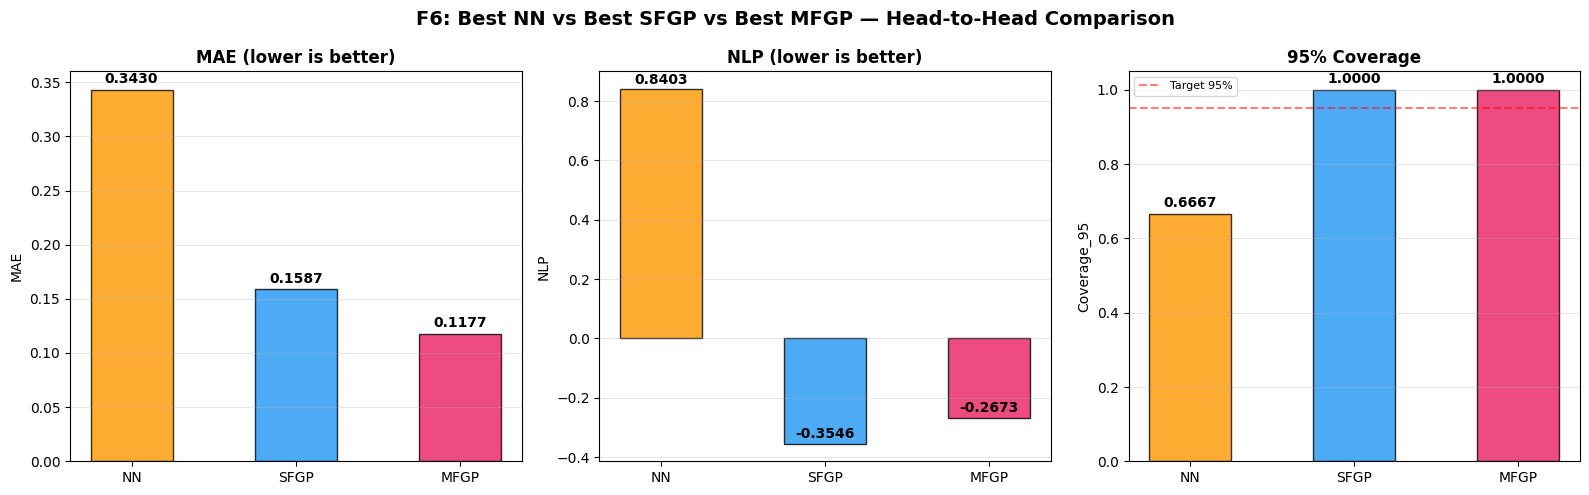

In [28]:
# ── Build comparison table ─────────────────────────────────────
comparison_data = [
    {
        'Model': 'NN',
        'Configuration': best_nn['label'],
        'MAE': best_nn['MAE'],
        'NLP': best_nn['NLP'],
        'Coverage_95': best_nn['Coverage_95']
    },
    {
        'Model': 'SFGP',
        'Configuration': best_sfgp['label'],
        'MAE': best_sfgp['MAE'],
        'NLP': best_sfgp['NLP'],
        'Coverage_95': best_sfgp['Coverage_95']
    },
    {
        'Model': 'MFGP',
        'Configuration': best_mfgp['label'],
        'MAE': best_mfgp['MAE'],
        'NLP': best_mfgp['NLP'],
        'Coverage_95': best_mfgp['Coverage_95']
    }
]

comparison_df = pd.DataFrame(comparison_data)

# Identify metric winners
mae_winner = comparison_df.loc[comparison_df['MAE'].idxmin(), 'Model']
nlp_winner = comparison_df.loc[comparison_df['NLP'].idxmin(), 'Model']
cov_diffs  = comparison_df['Coverage_95'].apply(lambda x: abs(x - 0.95))
cov_winner = comparison_df.loc[cov_diffs.idxmin(), 'Model']

print('='*80)
print('3-WAY COMPARISON — BEST OF EACH FAMILY')
print('='*80)
print(f'\nMAE Winner:      {mae_winner}')
print(f'NLP Winner:      {nlp_winner}')
print(f'Coverage Winner: {cov_winner}\n')
print(comparison_df.to_string(index=False))

# ── Bar chart comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = comparison_df['Model'].values
colors = ['#FF9800', '#2196F3', '#E91E63']  # Orange = NN, Blue = SFGP, Pink = MFGP

for ax, metric, title, direction in [
    (axes[0], 'MAE',         'MAE (lower is better)', 'lower'),
    (axes[1], 'NLP',         'NLP (lower is better)', 'lower'),
    (axes[2], 'Coverage_95', '95% Coverage',          'target'),
]:
    vals = comparison_df[metric].values
    bars = ax.bar(models, vals, color=colors, edgecolor='black', alpha=0.8, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Annotate values
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    if metric == 'Coverage_95':
        ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='Target 95%')
        ax.legend(fontsize=8)

plt.suptitle('F6: Best NN vs Best SFGP vs Best MFGP — Head-to-Head Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Best Model Visualisation

We re-run the overall winner (lowest NLP across all three families) and plot its prequential evaluation results — predictions vs actuals with 95% confidence interval, absolute error per step, and NLP contribution per step.

Overall Winner: SFGP — SF: matern_1.5, standardise, noise>=1e-08
  MAE:       0.158668
  NLP:       -0.3546
  Coverage:  100.0%



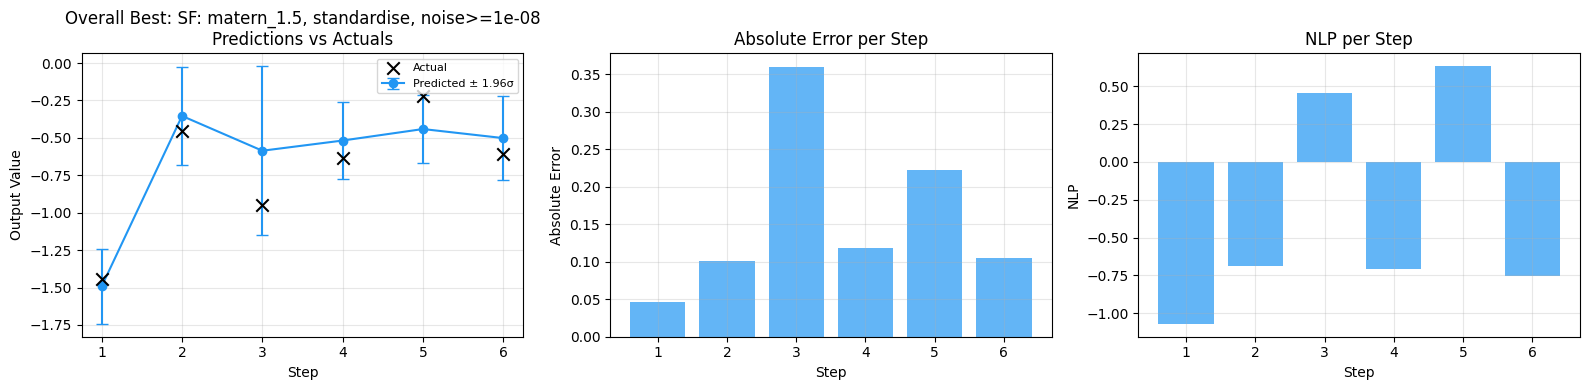

In [29]:
# ── Determine overall winner and re-run ───────────────────────
overall_winner = nlp_winner  # from the comparison cell above

if overall_winner == 'NN':
    best_label = best_nn['label']
    best_config = next(c for c in nn_configs if c['label'] == best_label)
    winner_results = nn_prequential_with_config(X_all, y_all, N_INIT, best_config)
    winner_color = '#FF9800'
elif overall_winner == 'SFGP':
    best_label = best_sfgp['label']
    best_config = next(c for c in sfgp_configs if c['label'] == best_label)
    winner_results = sfgp_prequential_with_config(X_all, y_all, N_INIT, best_config)
    winner_color = '#2196F3'
else:
    best_label = best_mfgp['label']
    best_config = next(c for c in mfgp_configs if c['label'] == best_label)
    winner_results = mfgp_prequential_with_config(X_all, y_all, N_INIT, best_config)
    winner_color = '#E91E63'

# Convert lists to numpy arrays for plotting
winner_results['predictions'] = np.array(winner_results['predictions'])
winner_results['actuals'] = np.array(winner_results['actuals'])
winner_results['stds'] = np.array(winner_results['stds'])

print(f'Overall Winner: {overall_winner} — {best_label}')
print(f'  MAE:       {winner_results["metrics"]["MAE"]:.6f}')
print(f'  NLP:       {winner_results["metrics"]["NLP"]:.4f}')
print(f'  Coverage:  {winner_results["metrics"]["Coverage_95"]*100:.1f}%\n')

# ── 3-panel prequential plot ──────────────────────────────────
plot_prequential_results(winner_results, f'Overall Best: {best_label}', color=winner_color)

## Sensitivity Analysis — All Configurations

Horizontal bar charts showing MAE, NLP, and 95% Coverage for all configurations from all three surrogate families. Colours: **NN = orange**, **SFGP = blue**, **MFGP = pink**.

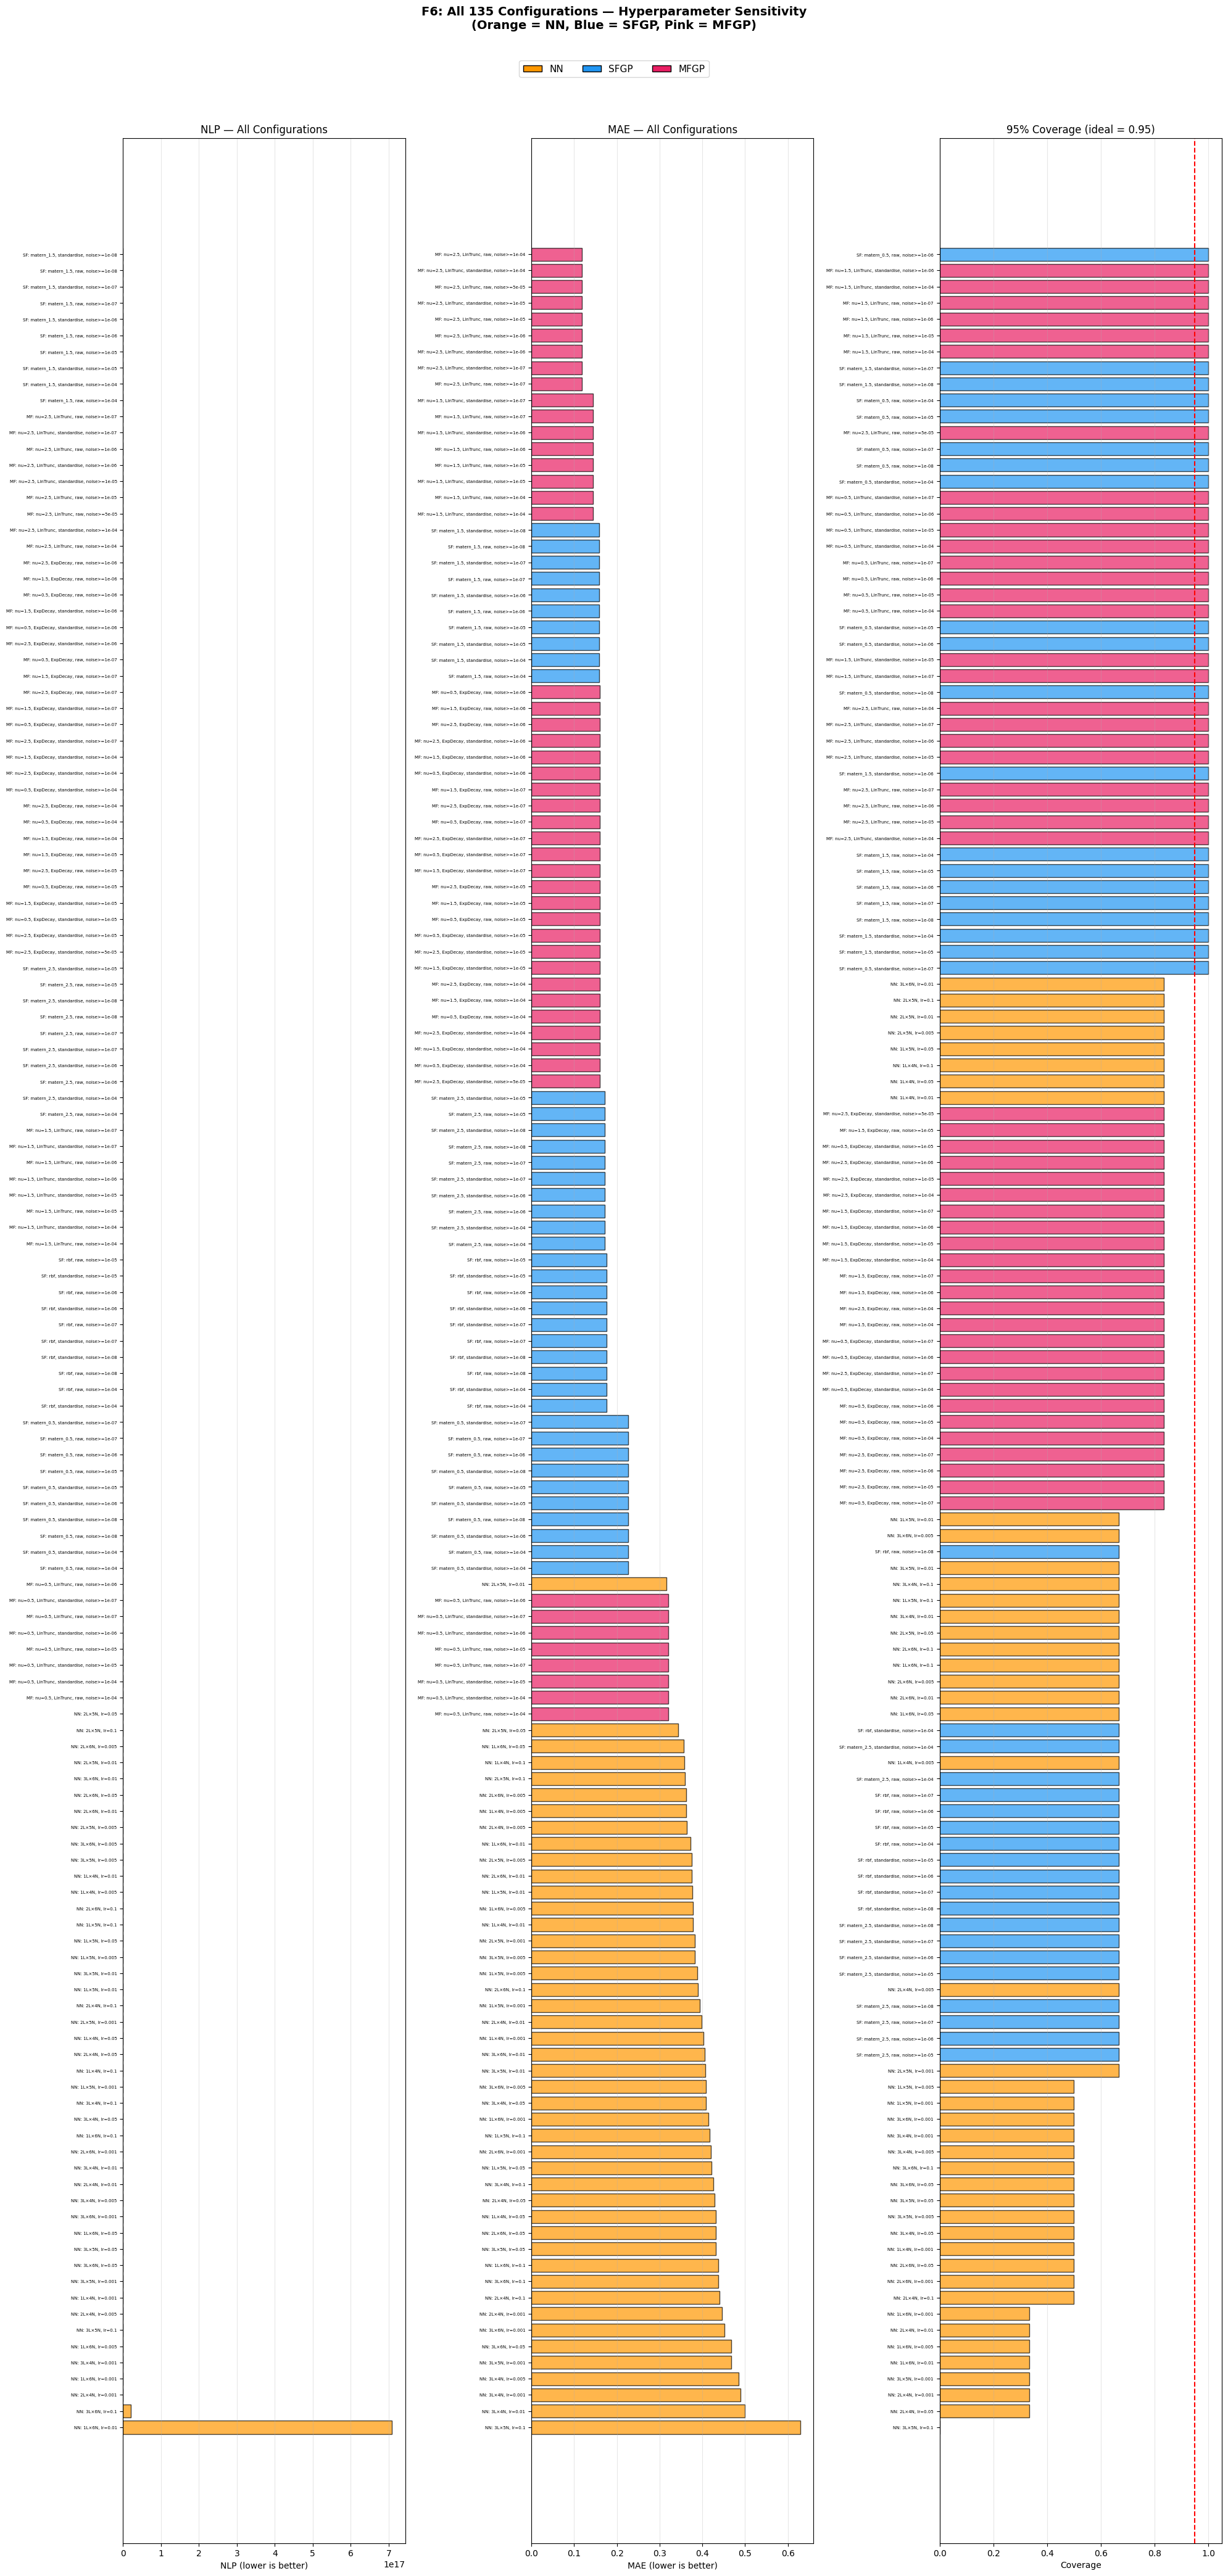

In [30]:
# ── Combined sensitivity bar charts ────────────────────────────
all_labels, all_mae, all_nlp, all_cov, all_colors = [], [], [], [], []

# NN configs (orange)
for _, row in nn_hp_df.iterrows():
    all_labels.append(row['label'])
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#FF9800')

# SFGP configs (blue)
for _, row in sfgp_hp_df.iterrows():
    all_labels.append(row['label'])
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#2196F3')

# MFGP configs (pink)
for _, row in mfgp_hp_df.iterrows():
    all_labels.append(row['label'])
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#E91E63')

n_configs = len(all_labels)
fig_height = max(16, n_configs * 0.3)
fig, axes = plt.subplots(1, 3, figsize=(20, fig_height))

# Sort by NLP
nlp_order = np.argsort(all_nlp)
sorted_labels  = [all_labels[i] for i in nlp_order]
sorted_nlp     = [all_nlp[i]    for i in nlp_order]
sorted_colors  = [all_colors[i] for i in nlp_order]
y_pos = np.arange(n_configs)

# NLP subplot
axes[0].barh(y_pos, sorted_nlp, color=sorted_colors, edgecolor='black', alpha=0.7)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(sorted_labels, fontsize=5)
axes[0].set_xlabel('NLP (lower is better)')
axes[0].set_title('NLP — All Configurations')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Sort by MAE
mae_order = np.argsort(all_mae)
mae_sorted_labels = [all_labels[i] for i in mae_order]
mae_sorted_vals   = [all_mae[i]    for i in mae_order]
mae_sorted_colors = [all_colors[i] for i in mae_order]

axes[1].barh(y_pos, mae_sorted_vals, color=mae_sorted_colors, edgecolor='black', alpha=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(mae_sorted_labels, fontsize=5)
axes[1].set_xlabel('MAE (lower is better)')
axes[1].set_title('MAE — All Configurations')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

# Sort by Coverage (descending — best at top)
cov_order = np.argsort(all_cov)[::-1]
cov_sorted_labels = [all_labels[i] for i in cov_order]
cov_sorted_vals   = [all_cov[i]    for i in cov_order]
cov_sorted_colors = [all_colors[i] for i in cov_order]

axes[2].barh(y_pos, cov_sorted_vals, color=cov_sorted_colors, edgecolor='black', alpha=0.7)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(cov_sorted_labels, fontsize=5)
axes[2].set_xlabel('Coverage')
axes[2].set_title('95% Coverage (ideal = 0.95)')
axes[2].axvline(x=0.95, color='red', linestyle='--', linewidth=1.5)
axes[2].invert_yaxis()
axes[2].grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF9800', edgecolor='black', label='NN'),
    Patch(facecolor='#2196F3', edgecolor='black', label='SFGP'),
    Patch(facecolor='#E91E63', edgecolor='black', label='MFGP'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.01))
plt.suptitle(f'F6: All {n_configs} Configurations — Hyperparameter Sensitivity\n'
             f'(Orange = NN, Blue = SFGP, Pink = MFGP)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Full Ranked Results — All Configurations

Combined ranked table of all NN, SFGP, and MFGP configurations, sorted by NLP (lower is better). The `Model` column identifies the surrogate family.

In [31]:
# ── Build full ranked table ────────────────────────────────────
nn_summary = nn_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
nn_summary.insert(0, 'Model', 'NN')
nn_summary = nn_summary.rename(columns={'label': 'Configuration'})

sfgp_summary = sfgp_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
sfgp_summary.insert(0, 'Model', 'SFGP')
sfgp_summary = sfgp_summary.rename(columns={'label': 'Configuration'})

mfgp_summary = mfgp_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
mfgp_summary.insert(0, 'Model', 'MFGP')
mfgp_summary = mfgp_summary.rename(columns={'label': 'Configuration'})

full_ranked = pd.concat([nn_summary, sfgp_summary, mfgp_summary], ignore_index=True)
full_ranked = full_ranked.sort_values('NLP').reset_index(drop=True)
full_ranked.index = full_ranked.index + 1  # 1-based ranking
full_ranked.index.name = 'Rank'

print(f'Full Ranked Results — All {len(full_ranked)} Configurations (sorted by NLP):\n')
full_ranked

Full Ranked Results — All 135 Configurations (sorted by NLP):



,Model,Configuration,MAE,NLP,Coverage_95
Rank,,,,,
1,SFGP,"SF: matern_1.5, standardise, noise>=1e-08",0.158668,-3.545868e-01,1.000000
2,SFGP,"SF: matern_1.5, raw, noise>=1e-08",0.158668,-3.545868e-01,1.000000
3,SFGP,"SF: matern_1.5, standardise, noise>=1e-07",0.158668,-3.545862e-01,1.000000
4,SFGP,"SF: matern_1.5, raw, noise>=1e-07",0.158668,-3.545862e-01,1.000000
5,SFGP,"SF: matern_1.5, standardise, noise>=1e-06",0.158670,-3.545801e-01,1.000000
...,...,...,...,...,...
131,NN,"NN: 3L×4N, lr=0.001",0.489593,8.651920e+01,0.500000
132,NN,"NN: 1L×6N, lr=0.001",0.413854,2.980581e+03,0.333333
133,NN,"NN: 2L×4N, lr=0.001",0.446610,1.318464e+04,0.333333


## Conclusions

### Key Findings

This notebook evaluated **three surrogate families** for Function 6 (cake recipe scoring — 5D input, negative output in [−2.57, −0.22]):

1. **Neural Network (NN)** — FlexibleNN with MC Dropout, varying layers {1,2,3}, nodes {4,5,6}, and learning rate (45 configs)
2. **Single Fidelity GP (SFGP)** — SingleTaskGP with ARD, varying kernel type, output transform, and noise floor (40 configs)
3. **Multi-Fidelity GP (MFGP)** — SingleTaskMultiFidelityGP with fidelity column, varying kernel type, smoothness, output transform, and noise floor (50 configs)

Key observations:
- The ranked results above show all 135 configurations from three families, sorted by NLP (lower is better)
- The 3-way comparison identifies the overall winner and metric-by-metric strengths
- NN uncertainty comes from MC Dropout (50 forward passes); SFGP and MFGP provide analytic uncertainty from the GP posterior
- SFGP uses 5D inputs directly; MFGP appends a fidelity column for a 6D input space
- F6's narrow, negative output range (−2.57 to −0.22) may favour one approach over the others depending on uncertainty calibration
- The best model visualisation confirms the winning configuration's prediction quality step by step

### Implications for Bayesian Optimisation

The overall best-calibrated configuration (lowest NLP) should be used as the surrogate model in the Bayesian Optimisation pipeline for Function 6. The choice between NN, SFGP, and MFGP affects both the acquisition function (UCB with MC Dropout vs analytic GP-based) and the computational cost per iteration.

### Next Steps

- Use the winning configuration in the main BO pipeline for F6
- Extend prequential evaluation to remaining functions (F7, F8)
- Consider whether the optimal surrogate family generalises across functions
- Investigate ensemble approaches combining NN, SFGP, and MFGP predictions